Data Points:
[ 1.   1.5  2.   2.2  2.5  8.   8.5  9.   9.5 10. ]

Cluster Labels:
[0 0 0 0 0 1 1 1 1 1]

Means of Gaussian Components:
[1.84 9.  ]

Mixing Probabilities:
[0.5 0.5]

Covariances:
[0.282401 0.500001]

Cluster Probabilities:
[[1.00000000e+00 4.20450655e-28]
 [1.00000000e+00 3.43415980e-25]
 [1.00000000e+00 4.12330340e-22]
 [1.00000000e+00 7.83185468e-21]
 [1.00000000e+00 7.27762060e-19]
 [2.40297763e-29 1.00000000e+00]
 [1.33713018e-34 1.00000000e+00]
 [5.06148935e-40 1.00000000e+00]
 [1.30335774e-45 1.00000000e+00]
 [2.28312463e-51 1.00000000e+00]]


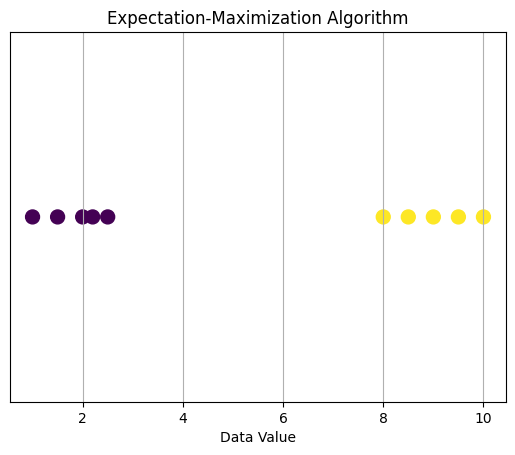

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Dataset
X = np.array([
    [1.0], [1.5], [2.0], [2.2], [2.5],
    [8.0], [8.5], [9.0], [9.5], [10.0]
])

# Create EM model with 2 Gaussian components
em = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

# Train the model using EM algorithm
em.fit(X)

# Predict cluster for each data point
labels = em.predict(X)

# Display results
print("Data Points:")
print(X.flatten())

print("\nCluster Labels:")
print(labels)

print("\nMeans of Gaussian Components:")
print(em.means_.flatten())

print("\nMixing Probabilities:")
print(em.weights_)

print("\nCovariances:")
print(em.covariances_.flatten())

# Display probability of each point belonging to each cluster
probabilities = em.predict_proba(X)

print("\nCluster Probabilities:")
print(probabilities)

# Plot clusters
plt.scatter(X, np.zeros_like(X), c=labels, s=100)
plt.xlabel("Data Value")
plt.title("Expectation-Maximization Algorithm")
plt.yticks([])
plt.grid(True)
plt.show()


In [2]:
# Credit Score Classification using Random Forest

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dataset
data = {
    'Age': [22, 25, 30, 35, 40, 45, 50, 28, 32, 38, 42, 55],
    'Income': [25000, 30000, 45000, 60000, 75000, 90000, 100000, 40000, 55000, 70000, 85000, 120000],
    'LoanAmount': [15000, 20000, 25000, 30000, 35000, 40000, 30000, 22000, 28000, 32000, 35000, 40000],
    'CreditHistory': [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1],
    'LatePayments': [5, 4, 3, 2, 1, 0, 0, 6, 2, 1, 4, 0],
    'CreditScore': [
        'Poor', 'Poor', 'Average', 'Average',
        'Good', 'Good', 'Good', 'Poor',
        'Average', 'Good', 'Average', 'Good'
    ]
}

df = pd.DataFrame(data)

# Features and target
X = df.drop('CreditScore', axis=1)
y = df['CreditScore']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Display results
print("Actual Credit Scores:")
print(list(y_test))

print("\nPredicted Credit Scores:")
print(list(y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy * 100, "%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Predict credit score for a new customer
new_customer = [[30, 50000, 25000, 1, 2]]

prediction = model.predict(new_customer)

print("\nNew Customer Credit Score:")
print(prediction[0])


Actual Credit Scores:
['Average', 'Good', 'Poor']

Predicted Credit Scores:
['Good', 'Good', 'Poor']

Accuracy: 66.66666666666666 %

Confusion Matrix:
[[0 1 0]
 [0 1 0]
 [0 0 1]]

Classification Report:
              precision    recall  f1-score   support

     Average       0.00      0.00      0.00         1
        Good       0.50      1.00      0.67         1
        Poor       1.00      1.00      1.00         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3


New Customer Credit Score:
Average


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [3]:
# Iris Flower Classification using KNN

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create KNN model
k = 5
model = KNeighborsClassifier(n_neighbors=k)

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display actual and predicted values
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy * 100, "%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

# Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("\nNew Flower Prediction:")
print(iris.target_names[prediction[0]])

Actual Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]

Predicted Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]

Accuracy: 100.0 %

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


New Flower Prediction:
setosa


In [4]:
# Car Price Prediction using Linear Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Create dataset
data = {
    'Age': [1, 2, 3, 4, 5, 6, 7, 8, 2, 4, 6, 9],
    'Kilometers': [10000, 18000, 25000, 35000, 45000, 55000,
                   65000, 75000, 15000, 30000, 50000, 85000],
    'Engine_CC': [1200, 1200, 1500, 1500, 1800, 1800,
                  2000, 2000, 1200, 1500, 1800, 2200],
    'Price': [850000, 780000, 700000, 620000, 550000, 480000,
              420000, 350000, 800000, 650000, 500000, 300000]
}

df = pd.DataFrame(data)

# Display dataset
print("Car Dataset:")
print(df)

# Features and target
X = df[['Age', 'Kilometers', 'Engine_CC']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display predictions
print("\nActual Prices:")
print(y_test.values)

print("\nPredicted Prices:")
print(y_pred)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:", mae)
print("R2 Score:", r2)

# Predict price of a new car
# Age = 3 years, Kilometers = 20000, Engine = 1500 CC
new_car = [[3, 20000, 1500]]

predicted_price = model.predict(new_car)

print("\nPredicted Price of New Car:")
print("₹", round(predicted_price[0], 2))

Car Dataset:
    Age  Kilometers  Engine_CC   Price
0     1       10000       1200  850000
1     2       18000       1200  780000
2     3       25000       1500  700000
3     4       35000       1500  620000
4     5       45000       1800  550000
5     6       55000       1800  480000
6     7       65000       2000  420000
7     8       75000       2000  350000
8     2       15000       1200  800000
9     4       30000       1500  650000
10    6       50000       1800  500000
11    9       85000       2200  300000

Actual Prices:
[500000 650000 850000]

Predicted Prices:
[496846.30738523 641037.9241517  838033.93213573]

Mean Absolute Error: 8027.27877578182
R2 Score: 0.996214302258083

Predicted Price of New Car:
₹ 700379.24


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
